# NYC Taxi Demand Analysis & Forecasting

This project analyzes NYC yellow taxi trip data to identify demand patterns, congestion trends, and short-term forecasting behavior. Using time-based aggregation and exploratory analysis, we uncover temporal structure in urban mobility and build a simple forecasting model for demand.

The goal is to understand:
- How taxi demand varies over time
- When congestion is most severe
- Whether short-term demand can be predicted using simple models

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

## Dataset

We use NYC yellow taxi trip data from three months (Jan–Mar 2023).  

Key fields include pickup time, trip distance, and fare information.

In [3]:
# load data
df1 = pd.read_parquet('data/yellow_tripdata_2022-08.parquet')
df2 = pd.read_parquet('data/yellow_tripdata_2022-09.parquet')
df3 = pd.read_parquet('data/yellow_tripdata_2022-10.parquet')

# combine
df = pd.concat([df1, df2, df3], ignore_index=True)

print(df.shape)

(10011855, 19)


## Data Cleaning & Feature Engineering

We convert timestamps, compute trip duration, and create time-based features for analysis.

In [4]:
# datetime conversion
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# trip duration
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# time features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date


# filter bad data
df = df[
    (df['trip_duration'] > 1) &
    (df['trip_duration'] < 120) &
    (df['trip_distance'] > 0)
]

# only looking at values from August to October
df = df[
    (df['pickup_date'] >= date(2022, 8, 1)) &
    (df['pickup_date'] <= date(2022, 10, 31))
]

print(df.shape)

(9784711, 23)


## Demand Over Time

We first examine how taxi demand evolves daily.

<Axes: title={'center': 'Trips Over Time'}, xlabel='pickup_date'>

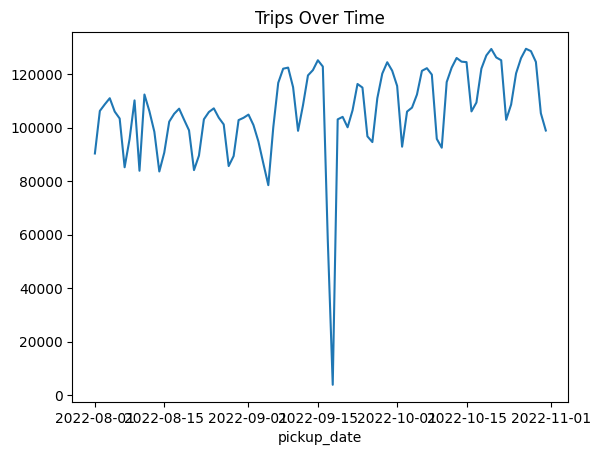

In [5]:
# plot demand over time
trips_by_date = df.groupby('pickup_date').size()
trips_by_date.plot(title='Trips Over Time')

Demand exhibits clear temporal variation, with fluctuations suggesting weekly structure.

## Hourly Demand Patterns

We analyze how demand varies throughout the day.

<Axes: title={'center': 'Trips by Month'}, xlabel='month'>

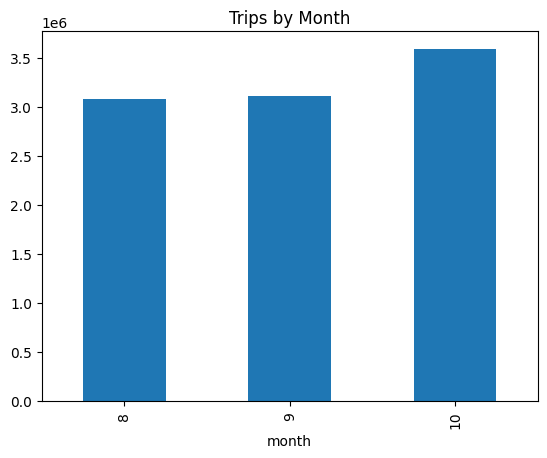

In [6]:
# plot compare months
df['month'] = df['tpep_pickup_datetime'].dt.month

trips_by_month = df.groupby('month').size()
trips_by_month.plot(kind='bar', title='Trips by Month')

Demand peaks during evening hours, consistent with commuting behavior.

## Weekday Patterns

We compare demand across days of the week.

<Axes: title={'center': 'Trips by Weekday'}, xlabel='pickup_weekday'>

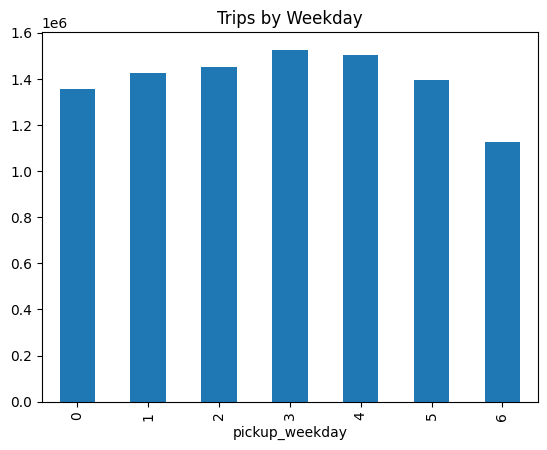

In [7]:
# plot weekday pickups
df['pickup_weekday'] = df['tpep_pickup_datetime'].dt.weekday
df.groupby('pickup_weekday').size().plot(kind='bar', title='Trips by Weekday')

## Congestion Analysis

We approximate congestion using average speed (distance / duration).

<Axes: title={'center': 'Congestion Rate by Hour'}, xlabel='pickup_hour'>

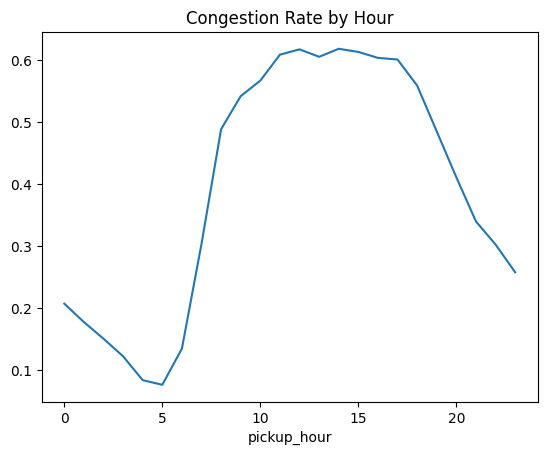

In [8]:
# plot congestion
df['speed_mph'] = df['trip_distance'] / (df['trip_duration'] / 60)
df['is_congested'] = df['speed_mph'] < 10

congestion_by_hour = df.groupby('pickup_hour')['is_congested'].mean()
congestion_by_hour.plot(title='Congestion Rate by Hour')

## Time Series Preparation

We aggregate trips by date to create a time series for forecasting.

In [9]:
df_ts = df.groupby('pickup_date').size()

# convert to datetime idx
df_ts.index = pd.to_datetime(df_ts.index)

df_ts = df_ts.sort_index()

df_ts.head()

pickup_date
2022-08-01     90289
2022-08-02    106199
2022-08-03    108670
2022-08-04    110955
2022-08-05    105957
dtype: int64

## Trend Visualization

We apply a rolling average to better observe underlying trends.

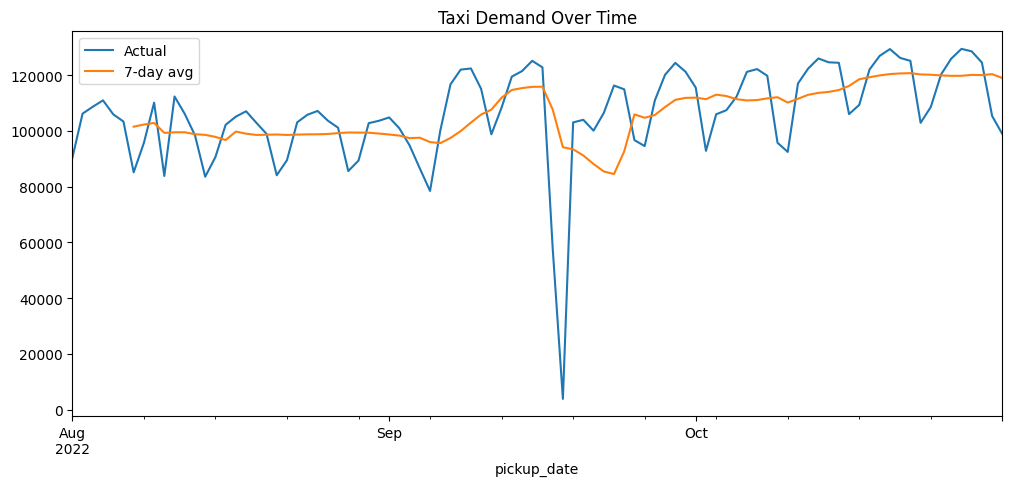

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
df_ts.plot(label='Actual')

df_ts.rolling(7).mean().plot(label='7-day avg')

plt.title("Taxi Demand Over Time")
plt.legend()
plt.show()

## Baseline Forecast

We use a naive model as a benchmark.

In [11]:
train = df_ts[:'2022-09-15']
test = df_ts['2022-09-16':]

# naive forecast (last value)
pred = test.copy()
pred[:] = train.iloc[-1]

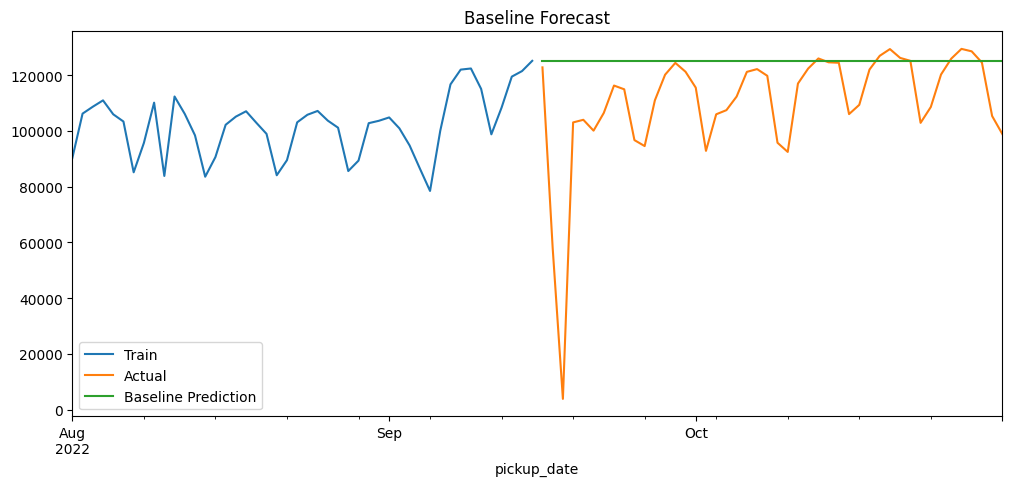

In [12]:
plt.figure(figsize=(12,5))
train.plot(label='Train')
test.plot(label='Actual')
pred.plot(label='Baseline Prediction')

plt.legend()
plt.title("Baseline Forecast")
plt.show()

## Moving Average Forecast

A rolling average provides a simple improvement over the baseline.

/var/folders/nx/_s8rrm1n4tdc5933rxmgrtg80000gn/T/ipykernel_53317/47072564.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '115809.42857142857' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pred_ma[:] = rolling_mean


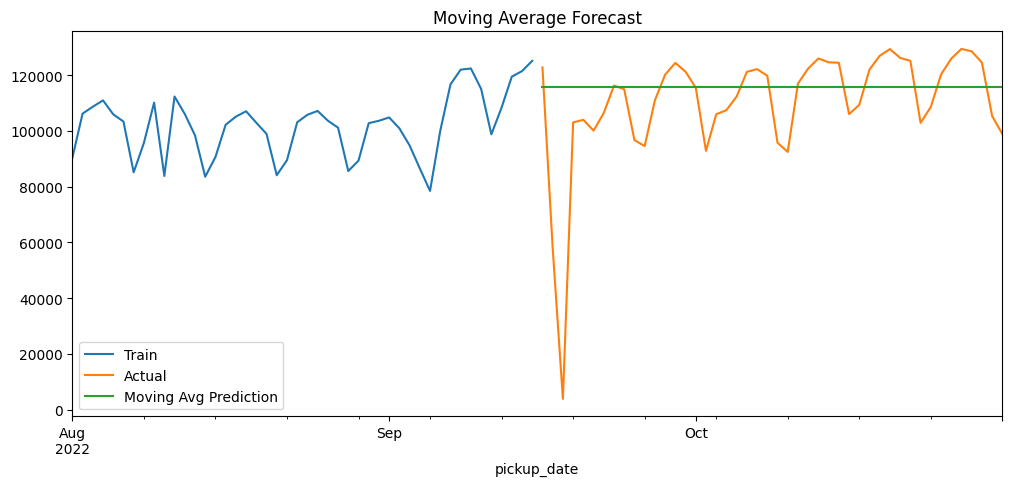

In [13]:
# rolling mean
pred_ma = test.copy()
rolling_mean = train.rolling(7).mean().iloc[-1]
pred_ma[:] = rolling_mean

plt.figure(figsize=(12,5))
train.plot(label='Train')
test.plot(label='Actual')
pred_ma.plot(label='Moving Avg Prediction')

plt.legend()
plt.title("Moving Average Forecast")
plt.show()

In [14]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, pred_ma)
print("MAE:", mae)

MAE: 12932.95652173913


## Key Findings

- Taxi demand shows consistent hourly and weekly patterns  
- Congestion aligns with peak demand periods  
- Simple forecasting models can capture short-term demand trends  
- Temporal structure suggests predictable behavior in urban mobility systems  